# 02 – Exploratory Data Analysis and Hypothesis Tests

Project: Developer Salary Prediction  
Data: `data/processed/survey_clean_2025.csv` (output of notebook 01, 7,428 employed professional developers in Europe)

Main question: Which factors are related to a developer's salary?

How I work in this notebook:
- Every section answers one question,
- Groups are compared with the median, because salaries are right-skewed,
- Tests that assume normality use the log salary (skewness −0.27 after cleaning, see notebook 01),
- Significance level α = 0.05, and next to each p-value I report how large the difference is.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid")

## 1. Load the data

The order of the ordered columns is not stored in a CSV file, so the order lists from notebook 01 are defined again here. I also add the log salary (log10, so 4 = 10,000 USD and 5 = 100,000 USD, as in notebook 01).

In [5]:
df = pd.read_csv("../data/processed/survey_clean_2025.csv")

target = "ConvertedCompYearly"
df["log_salary"] = np.log10(df[target])

edlevel_order = ["Secondary or lower", "Some college", "Associate", "Bachelor", "Master", "Doctorate/professional"]
orgsize_order = ["<20", "20-99", "100-499", "500-999", "1,000-4,999", "5,000-9,999", "10,000+"]
age_order = ["18-24", "25-34", "35-44", "45-54", "55+"]

lang_cols = [col for col in df.columns if col.startswith("lang_")]

print(df.shape)
print("Language columns:", len(lang_cols))
df.head()


(7428, 57)
Language columns: 42


,ResponseId,ConvertedCompYearly,WorkExp,YearsCode,Country,DevType,EdLevel,OrgSize,RemoteWork,Industry,...,lang_Ruby,lang_Rust,lang_SQL,lang_Scala,lang_Swift,lang_TypeScript,lang_VBA,lang_Visual Basic,lang_Zig,log_salary
0,2,104413.0,2.0,10.0,Netherlands,Back-end developer,Associate,500-999,Hybrid (mostly flexible),Retail & consumer,...,0,0,0,0,0,0,0,0,0,5.018755
1,28,209643.0,24.0,36.0,Sweden,Full-stack developer,Bachelor,"1,000-4,999",Hybrid (mostly in-person),Banking & finance,...,0,0,1,0,0,0,0,0,0,5.321480
2,36,95132.0,10.0,10.0,Germany,Back-end developer,Bachelor,"1,000-4,999",Own choice,Higher education,...,0,0,1,0,0,1,0,0,0,4.978327
3,39,91215.0,25.0,25.0,United Kingdom,Full-stack developer,Master,<20,Remote,Software development,...,0,0,1,0,0,1,0,0,0,4.960066
4,44,43810.0,8.0,14.0,Czech Republic,Other developer,Master,100-499,Remote,Software development,...,0,0,0,0,0,0,0,0,0,4.641573


## 2. Univariate analysis

One column at a time: how is it distributed, and how large are the groups? This shows what to watch out for in the comparisons later.

### U1. How are salaries distributed, and what changes on the log scale?

The shape of the target decides two things: whether the tests can use the raw salary, and whether a log target is worth trying in the model.

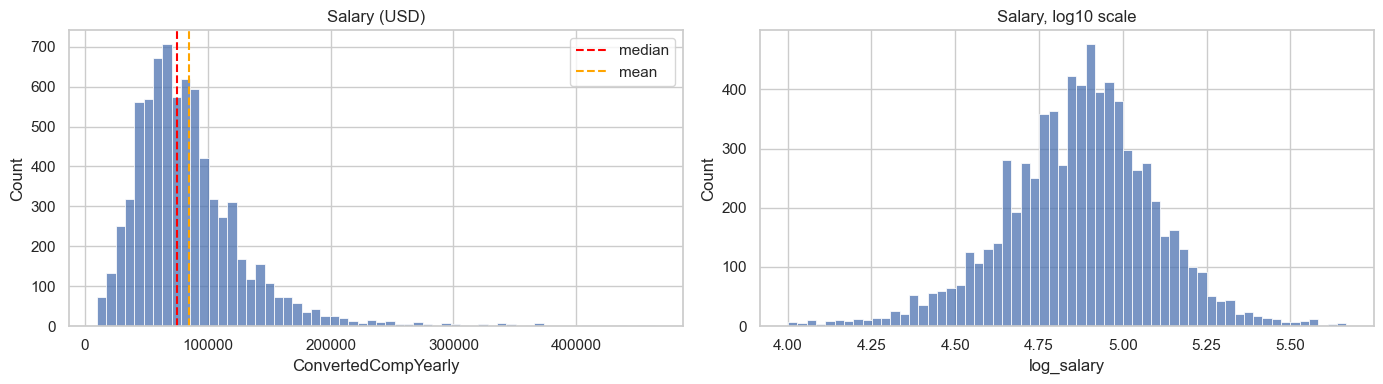

Median: 75,410 USD   Mean: 84,522 USD
Skewness raw: 2.19   Skewness log: -0.27


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[target], bins=60, ax=axes[0])
axes[0].axvline(df[target].median(), color="red", linestyle="--", label="median")
axes[0].axvline(df[target].mean(), color="orange", linestyle="--", label="mean")
axes[0].set_title("Salary (USD)")
axes[0].legend()

sns.histplot(df["log_salary"], bins=60, ax=axes[1])
axes[1].set_title("Salary, log10 scale")

plt.tight_layout()
plt.show()

print(f"Median: {df[target].median():,.0f} USD   Mean: {df[target].mean():,.0f} USD")
print(f"Skewness raw: {df[target].skew():.2f}   Skewness log: {df['log_salary'].skew():.2f}")

Notes:
- Salaries are right-skewed: most people earn 60,000 to 80,000 USD, with a long tail up to about 470,000 USD. The mean (84,522) is about 9,000 USD above the median (75,410). Before cleaning, this gap was about 26,000 USD.
- On the log scale the distribution is almost symmetric, with a peak around 4.9 (about 80,000 USD). The left tail is a bit longer, which explains the slightly negative skewness (−0.27).
- Some bars stick out from their neighbours. This comes from round salaries (e.g. 50,000 or 60,000 EUR), which pile up at the same values. It's a reporting pattern, not an error.
- So: medians for group comparisons, log salary for tests that assume normality, and a log target is worth trying in the model.

### U2. How are experience and the number of languages distributed?

`WorkExp`, `YearsCode` and `n_languages` are the numeric features. A skewed feature can mean that its relation with salary is not linear.

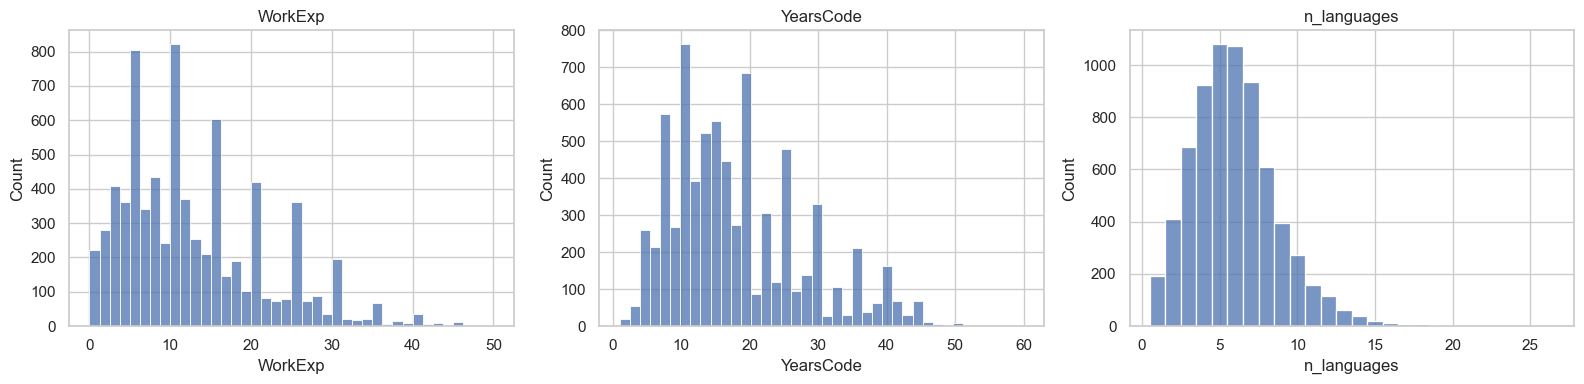

,WorkExp,YearsCode,n_languages
count,7428.0,7409.0,7009.0
mean,12.8,18.2,6.0
std,8.7,9.8,2.8
min,0.0,1.0,1.0
25%,6.0,10.0,4.0
50%,11.0,16.0,6.0
75%,18.0,25.0,7.0
max,50.0,60.0,26.0


In [8]:
numeric_features = ["WorkExp", "YearsCode", "n_languages"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], bins=40, discrete=(col == "n_languages"), ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

df[numeric_features].describe().round(1)



Notes:
- `WorkExp` and `YearsCode` show peaks at round numbers (5, 10, 15, 20, 25, 30 years). People round their experience, so "10 years" can mean anything from about 8 to 12. This is a reporting pattern (heaping), not an error, but year-to-year differences shouldn't be over-interpreted.
- `WorkExp` is slightly right-skewed (median 11, mean 12.8). The minimum is now 0: the 41 blanks recoded in notebook 01.
- `YearsCode` looks similar but is shifted by about 5 years (median 16), because it includes education. It still has 19 missing values, which are imputed in notebook 03.
- `n_languages`: median 6, half of the people use 4 to 7 languages, maximum 26. The gaps between the bars come from whole-number values and narrow bins, not from the data. 419 missing values (people without language data).
- Both experience columns are skewed, so their relation with salary may not be linear. This is checked in B1.

### U3. How large are the groups in the categorical columns?

Small groups give unreliable medians and weak test results, so I check the group sizes before comparing salaries. Ordered columns are shown in their natural order, the others from largest to smallest.

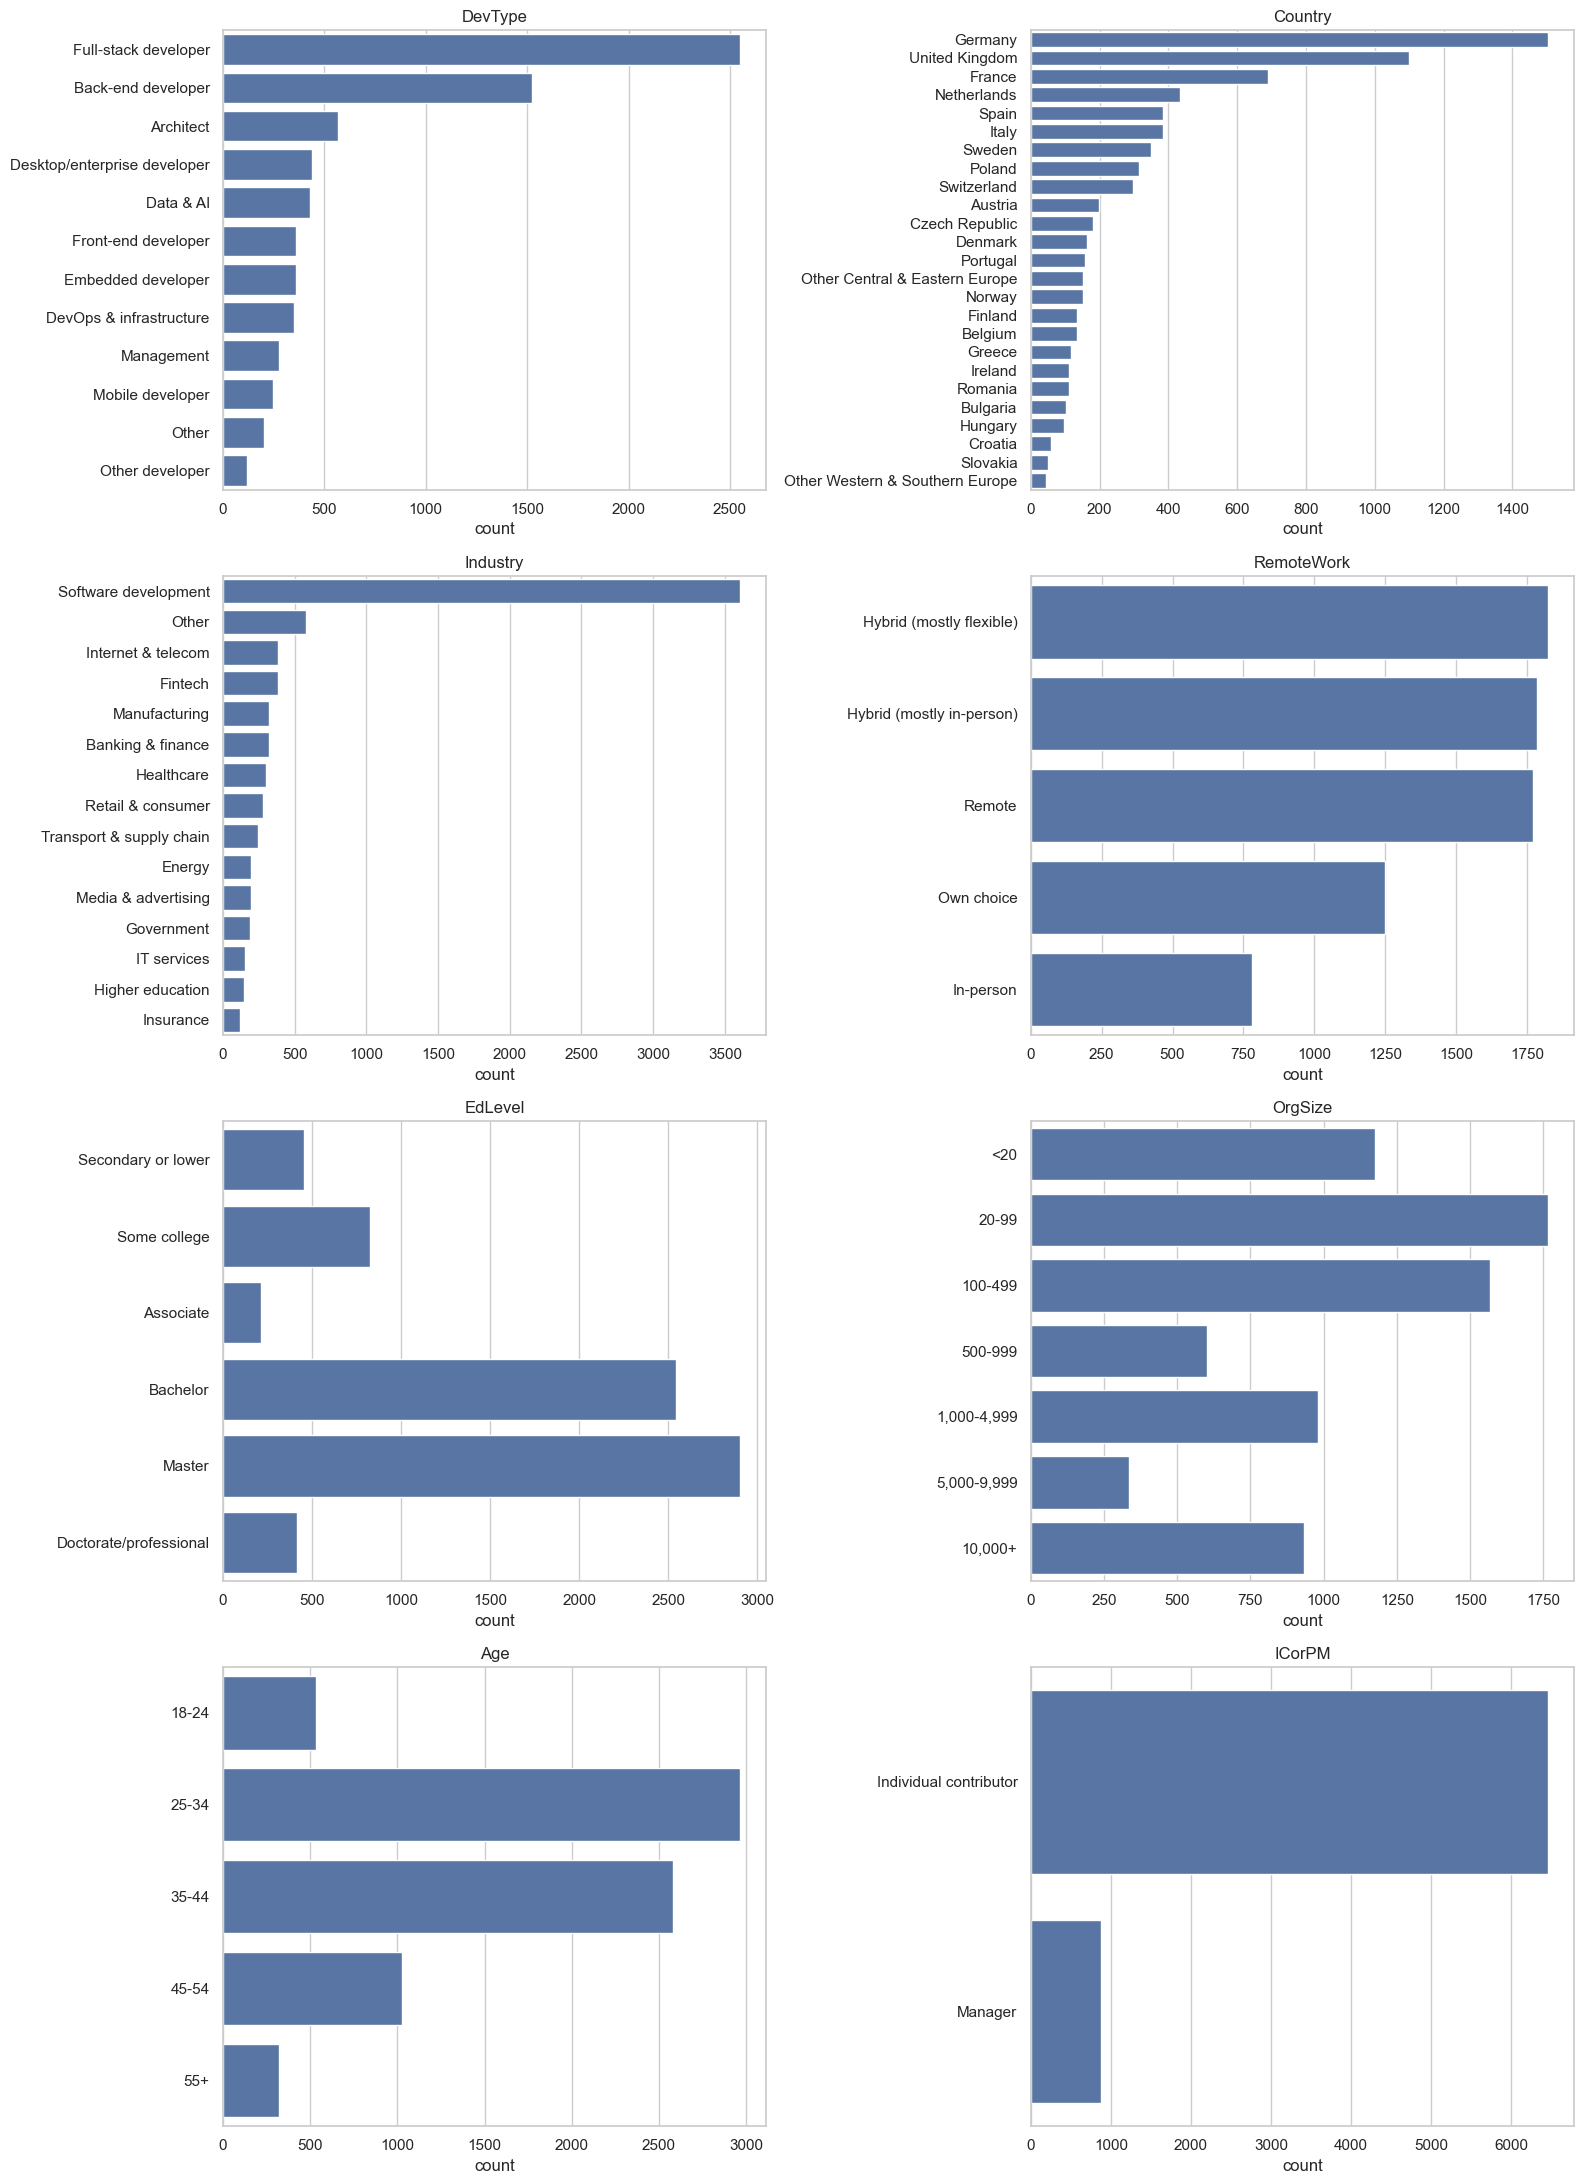

In [5]:
categorical_plots = [
    ("DevType", None), ("Country", None), ("Industry", None), ("RemoteWork", None),
    ("EdLevel", edlevel_order), ("OrgSize", orgsize_order), ("Age", age_order), ("ICorPM", None),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
for ax, (col, order) in zip(axes.flat, categorical_plots):
    if order is None:
        order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

Notes:
- No group is very small after the grouping in notebook 01 (smallest: 44 in Country, 121 in DevType). But almost every column is unbalanced, with one or two groups covering most of the data.
- `DevType`: full-stack and back-end developers are more than half of the data.
- `Country`: Germany (about 1,500) and the UK (about 1,100) dominate. Germany is the best choice for checks within one country (e.g. remote work in T3). Medians of the small countries are less reliable.
- `Industry`: "Software development" is about half of the data and "Other" is the second largest group (602), which limits what the industry comparison can show.
- `RemoteWork`: the most balanced column. About half of the people work hybrid; in-person is the smallest group (780).
- `EdLevel`: Master and Bachelor make up about 75%. "Associate" (213) is a US-type degree and rare in Europe.
- `Age`: 25–34 and 35–44 make up about three quarters, in line with a median work experience of 11 years.
- `ICorPM`: about 88% individual contributors and 12% managers, so T2 uses Welch's t-test (`equal_var=False`).

### U4. How common is each programming language?

This prepares the choice of languages for the model (made in notebook 03 on the training data only). The red line marks 5% of respondents.

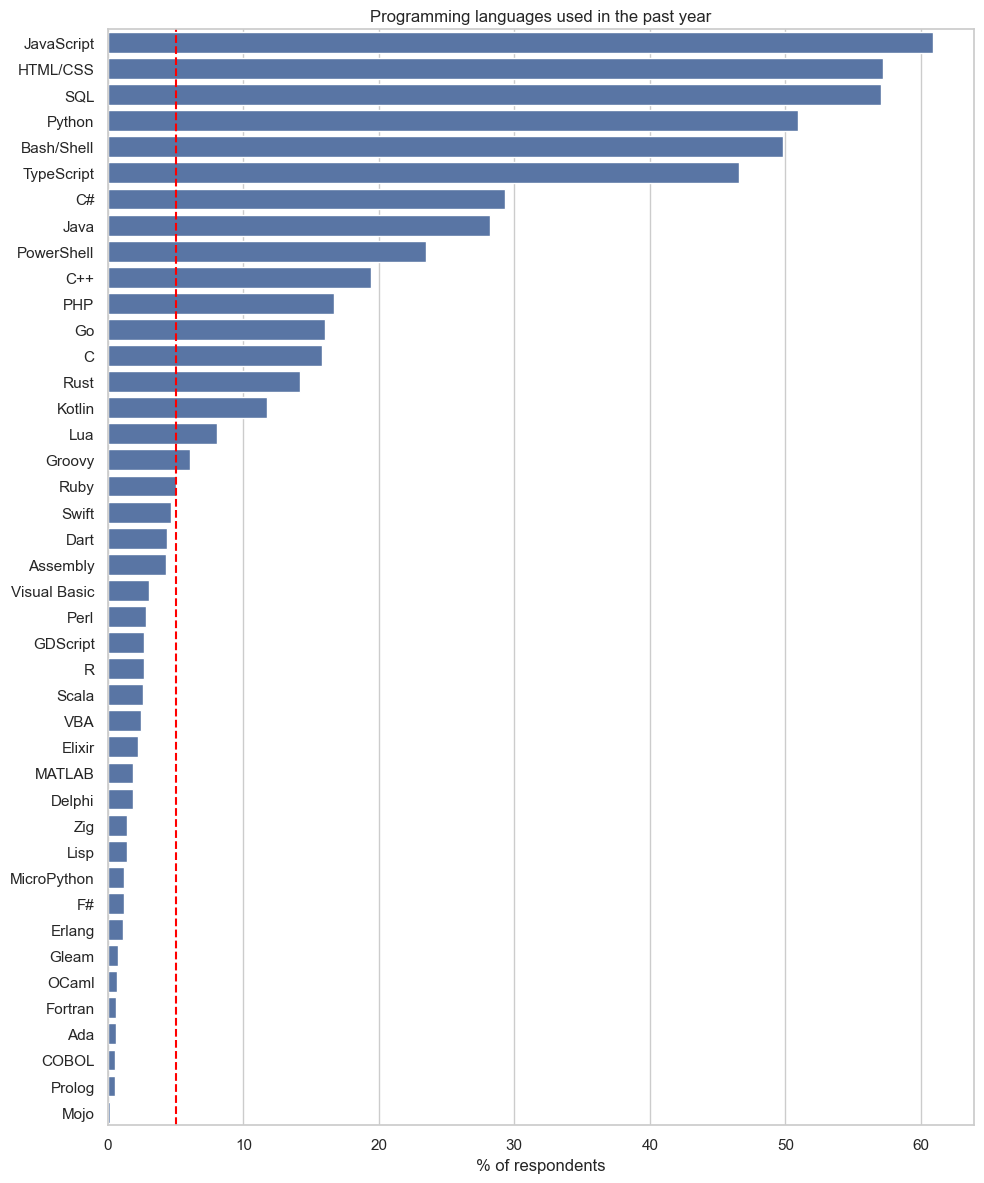

Languages used by at least 5%: 18


In [9]:
lang_share = (df[lang_cols].mean() * 100).sort_values(ascending=False)
lang_share.index = lang_share.index.str.replace("lang_", "")

fig, ax = plt.subplots(figsize=(10, 12))
sns.barplot(x=lang_share.values, y=lang_share.index, ax=ax)
ax.axvline(5, color="red", linestyle="--")
ax.set_xlabel("% of respondents")
ax.set_ylabel("")
ax.set_title("Programming languages used in the past year")
plt.tight_layout()
plt.show()

print("Languages used by at least 5%:", (lang_share >= 5).sum())

Notes:
- Six languages are used by about half of the respondents or more: JavaScript (61%), HTML/CSS, SQL, Python, Bash/Shell and TypeScript.
- C#, Java, PowerShell, C++, PHP, Go, C, Rust and Kotlin (12–29%) are more tied to specific types of work, such as enterprise software, systems programming or mobile.
- 18 languages are above 5% (Ruby is right at the line); 24 are below, some used by only a handful of people.
- These shares include the 419 people without language data (all 0), so they are slightly too low. Among people with language data, JavaScript is at about 65%. The ranking doesn't change.
- In B11, only the 18 languages above 5% are compared, and people without language data are left out. Which languages go into the model is decided in notebook 03, on the training data only.

## Next steps
- Bivariate analysis: each feature against salary (B1 to B11)
- Relations between features (F1 to F3)
- Hypothesis tests (T1 to T6)